# Глава 3. MovingAverageModel — скользящее среднее


## 1. Теория

### 1.1 Идея скользящего среднего

Прогноз — это среднее арифметическое последних `window` значений ряда, а не единственное последнее значение, как у `NaiveModel`:

$$\large y_t = \frac{1}{n}\sum_{i=1}^{n} y_{t-i}$$

где:
- $y_t$ — прогнозируемое значение в момент времени $t$;
- $n$ — размер окна (`window`) — сколько последних точек усредняем;
- $y_{t-i}$ — значение $i$ шагов назад от $t$: факт, если он ещё в пределах истории, или уже собственный прогноз модели (см. раздел 1.3).

При `window=1` формула вырождается в единственное последнее значение — то есть в прогноз `NaiveModel(lag=1)`. Это не приблизительное сходство, а буквальное совпадение прогнозов, проверишь сам в Задании 3.


### 1.2 Параметры и реализация

Исходник `etna/models/moving_average.py`:

```python
class MovingAverageModel(SeasonalMovingAverageModel):
    def __init__(self, window: int = 5):
        self.window = window
        super().__init__(window=window, seasonality=1)
```

**Параметры `MovingAverageModel`:**
- `window` *(int, по умолчанию `5`)* — размер окна усреднения; единственный параметр, который можно менять снаружи.
- `seasonality` — внутренний параметр родительского класса `SeasonalMovingAverageModel`, зафиксирован равным `1`, наружу не выведен.

**В отличие от `NaiveModel`:**
- нет параметра `lag` вообще — сдвиг относительно текущей точки не настраивается;
- `context_size = window * seasonality = window` (у `NaiveModel` было `context_size = lag`);
- прогноз — это среднее по `window` точкам, а не единственная точка.


### 1.3 Особенности

- **Рекурсия неизбежна, начиная со второго шага горизонта.** Формула рекурсивного прогноза одна для всей семьи `SeasonalMovingAverageModel`: `res[i] = res[i - context_size : i : seasonality].mean(axis=0)`. При `seasonality=1` шаг окна равен `1` — окно всегда прилегает вплотную к точке `i`, без «перепрыгивания». Значит окно для **второго** прогнозного шага (`i = context_size + 1`) обязательно захватывает первый прогноз (`res[context_size]`) — сколько бы ни было `window`, хоть `5`, хоть `50`. У `NaiveModel` правило `lag ≥ horizon` полностью защищает от рекурсии — у `MovingAverageModel` такого предохранителя нет вообще.
- `window` не защищает от рекурсии — он её **замедляет**.



## 2. Данные

Те же файлы, что и в тетради про `NaiveModel` (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.
- `forecasts-by-date.csv` — дневной прогноз текущей продовой модели, доступен за 2026-06-01…2026-08-31.
- `facts-by-hour.csv` / `forecasts-by-hour.csv` — почасовая гранулярность, если захочешь заглянуть вперёд.


In [1]:
import numpy as np
import pandas as pd

from etna.datasets import TSDataset
from etna.models import MovingAverageModel, NaiveModel
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

DATA_DIR = "../../local/data"


/Users/skv/projects-skv/study-etna/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Практика




### Задание 1. Синтетика: `window` гасит тренд, а не продолжает его

1. Сгенерируй синтетический ряд с чистым линейным трендом, без шума (например, `target = np.arange(...)`).
2. Выбери `HORIZON` и раздели ряд так, чтобы тестовый отрезок целиком лежал на продолжении тренда.
3. Обучи `MovingAverageModel` для маленького `window` (например, 2–3) и заметно большего горизонта (например, `window = 2 * HORIZON`), визуализируй оба прогноза через `plot_forecast`.
4. Вопросы:
    - продолжает ли прогноз тренд хоть при каком-то `window`?
    - что с ним происходит и с какой скоростью — при маленьком и при большом `window`?
    - почему это происходит?

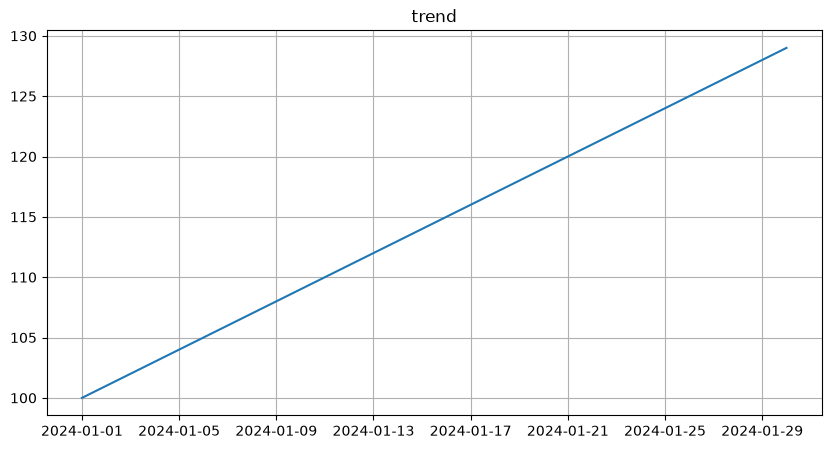

In [2]:
periods = 30
df = pd.DataFrame({
    "timestamp": pd.date_range("2024-01-01", periods=periods, freq="D"),
    "segment": "trend",
    "target": np.arange(periods, dtype=float) + 100.0,  # чистый линейный тренд, без шума
})
ts = TSDataset(TSDataset.to_dataset(df), freq="D")

ts.plot()

In [16]:
def get_forecast(data, horizon, window, seasonality=1, is_log=True):

    train_ts, test_ts = data.train_test_split(test_size=horizon)

    # Магия ETNA
    model = MovingAverageModel(window=window)
    model.fit(train_ts)
    future = train_ts.make_future(future_steps=horizon, tail_steps=model.context_size)
    forecast_ts = model.forecast(ts=future, prediction_size=horizon)

    if not is_log:
        return train_ts, test_ts, forecast_ts

    # А теперь воспроизведем полученные результаты руками, что бы понимать.
    shift = window * seasonality

    # Выбираем target из обучающей выборки
    targets = train_ts.to_pandas(flatten=True)["target"]

    # Выбираем контекст модели из обучающей выборки. аналог make_future(tail_steps=model.context_size)
    series = targets[-shift:].values

    # Создаем массив из shifts и горизонта прогноза заполненного нулями
    result = np.append(series, np.zeros(horizon))

    print(f"Заготовка: [{', '.join([f'{x:>.1f}' for x in result])}]\n")

    for i in range(shift, len(result)):
        step_num = i - shift + 1
        current_window = result[i - shift : i : seasonality]

        window_indices = range(i - shift, i, seasonality)
        n_facts = sum(1 for idx in window_indices if idx < shift)
        n_preds = sum(1 for idx in window_indices if idx >= shift)

        result[i] = current_window.mean()

        window_str = ", ".join([f"{x:>.1f}" for x in current_window])
        print(
            f"Шаг {step_num:<2} | "
            f"Окно: [{window_str:<38}] | "
            f"Факты/Прогнозы: {n_facts}/{n_preds} | "
            f"Среднее: {result[i]:<10.2f} | "
            f"Позиция: {i:<2}"
        )

    plot_forecast(forecast_ts=forecast_ts, test_ts=test_ts, train_ts=train_ts, n_train_samples=horizon)

Заготовка: [118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [118.0, 119.0                          ] | Факты/Прогнозы: 2/0 | Среднее: 118.50     | Позиция: 2 
Шаг 2  | Окно: [119.0, 118.5                          ] | Факты/Прогнозы: 1/1 | Среднее: 118.75     | Позиция: 3 
Шаг 3  | Окно: [118.5, 118.8                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.62     | Позиция: 4 
Шаг 4  | Окно: [118.8, 118.6                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.69     | Позиция: 5 
Шаг 5  | Окно: [118.6, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.66     | Позиция: 6 
Шаг 6  | Окно: [118.7, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.67     | Позиция: 7 
Шаг 7  | Окно: [118.7, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.66     | Позиция: 8 
Шаг 8  | Окно: [118.7, 118.7                          ] | Факты/Прогнозы: 0/2 | Среднее: 118.67     | Позиция: 9 
Шаг 9  | Ок

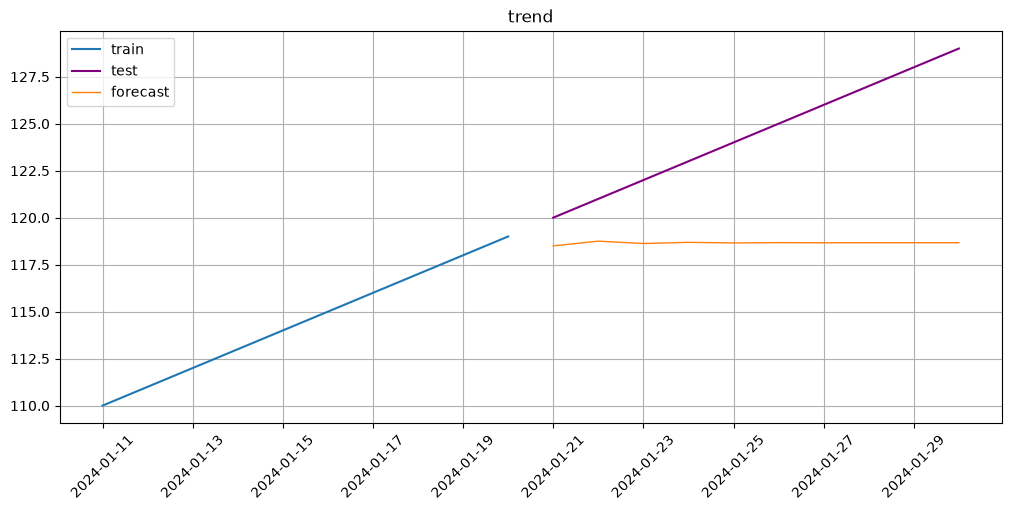

In [17]:
get_forecast(data=ts, horizon=10, window=2)

Заготовка: [115.0, 116.0, 117.0, 118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [115.0, 116.0, 117.0, 118.0, 119.0     ] | Факты/Прогнозы: 5/0 | Среднее: 117.00     | Позиция: 5 
Шаг 2  | Окно: [116.0, 117.0, 118.0, 119.0, 117.0     ] | Факты/Прогнозы: 4/1 | Среднее: 117.40     | Позиция: 6 
Шаг 3  | Окно: [117.0, 118.0, 119.0, 117.0, 117.4     ] | Факты/Прогнозы: 3/2 | Среднее: 117.68     | Позиция: 7 
Шаг 4  | Окно: [118.0, 119.0, 117.0, 117.4, 117.7     ] | Факты/Прогнозы: 2/3 | Среднее: 117.82     | Позиция: 8 
Шаг 5  | Окно: [119.0, 117.0, 117.4, 117.7, 117.8     ] | Факты/Прогнозы: 1/4 | Среднее: 117.78     | Позиция: 9 
Шаг 6  | Окно: [117.0, 117.4, 117.7, 117.8, 117.8     ] | Факты/Прогнозы: 0/5 | Среднее: 117.54     | Позиция: 10
Шаг 7  | Окно: [117.4, 117.7, 117.8, 117.8, 117.5     ] | Факты/Прогнозы: 0/5 | Среднее: 117.64     | Позиция: 11
Шаг 8  | Окно: [117.7, 117.8, 117.8, 117.5, 117.6     ] | Факты/Прогнозы: 0/5 | Среднее: 117.69     | По

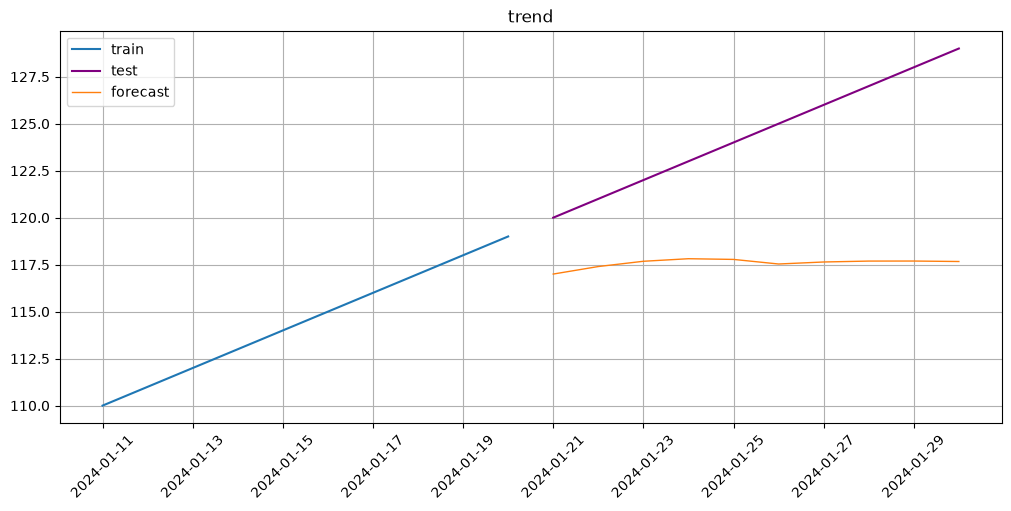

In [5]:
get_forecast(data=ts, horizon=10, window=5)

Заготовка: [110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0] | Факты/Прогнозы: 10/0 | Среднее: 114.50     | Позиция: 10
Шаг 2  | Окно: [111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5] | Факты/Прогнозы: 9/1 | Среднее: 114.95     | Позиция: 11
Шаг 3  | Окно: [112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0] | Факты/Прогнозы: 8/2 | Среднее: 115.34     | Позиция: 12
Шаг 4  | Окно: [113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0, 115.3] | Факты/Прогнозы: 7/3 | Среднее: 115.68     | Позиция: 13
Шаг 5  | Окно: [114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0, 115.3, 115.7] | Факты/Прогнозы: 6/4 | Среднее: 115.95     | Позиция: 14
Шаг 6  | Окно: [115.0, 116.0, 117.0, 118.0, 119.0, 114.5, 115.0, 115.3, 115.7, 115.9] | Факты/Прогнозы: 5/5 | Среднее: 116.14     | Позиция: 15
Ша

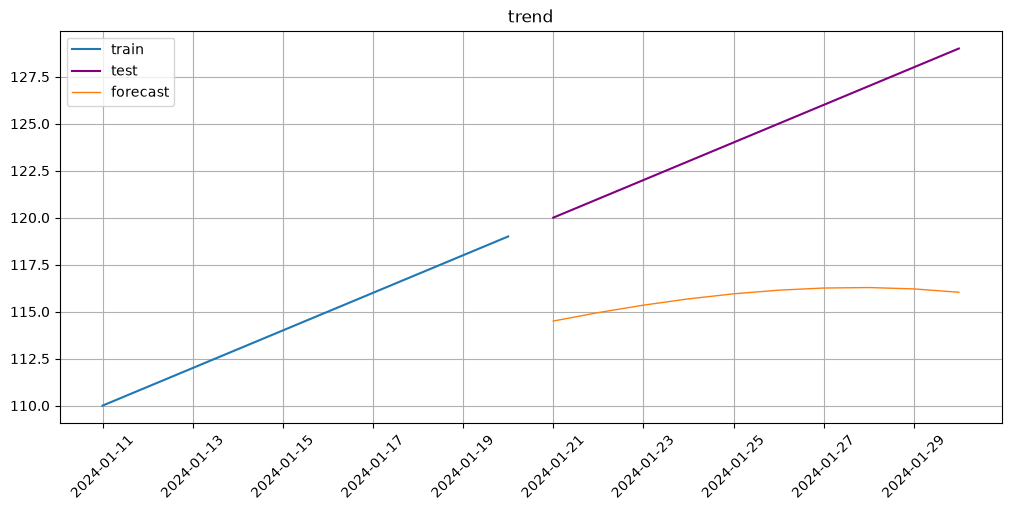

In [6]:
get_forecast(data=ts, horizon=10, window=10)

Заготовка: [100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0] | Факты/Прогнозы: 20/0 | Среднее: 109.50     | Позиция: 20
Шаг 2  | Окно: [101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 109.5] | Факты/Прогнозы: 19/1 | Среднее: 109.97     | Позиция: 21
Шаг 3  | Окно: [102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 109.5, 110.0] | Факты/Прогнозы: 18/2 | Среднее: 110.42     | Позиция: 22
Шаг 4  | Окно: [103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 109.5, 110.0, 110

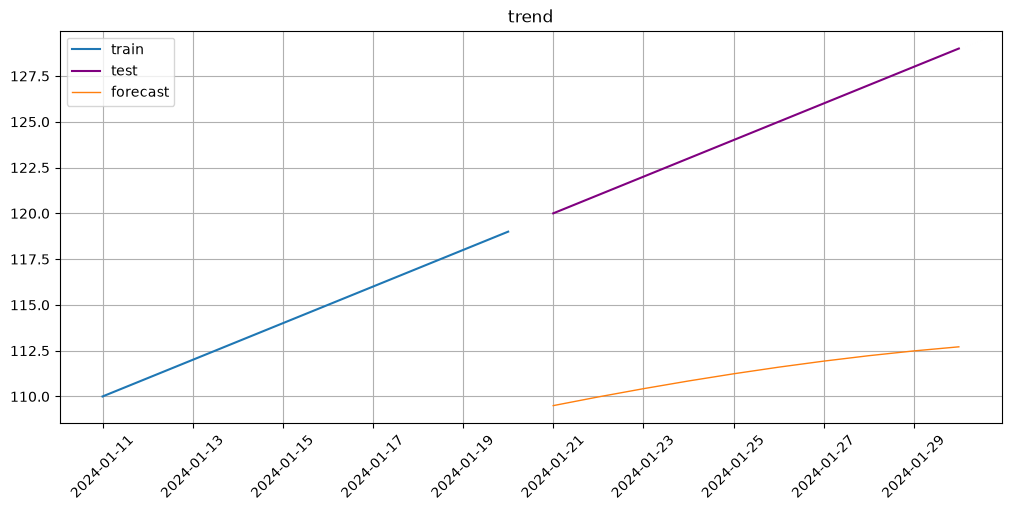

In [7]:
get_forecast(data=ts, horizon=10, window=20)

1. **Продолжает ли прогноз тренд хоть при каком-то window?** Нет, по-настоящему нет ни при каком window. При окне меньше горизонта тренд очень быстро затухает в константу. При окне горизонт×2 появляется только видимость направления — прогноз растёт в ту же сторону, что и тренд, но прогноз не продолжает тренд.

2. **Что с ним происходит и с какой скоростью — при маленьком и при большом window?** При маленьком окне прогноз быстро (за несколько шагов) затухает в плоскую линию. При большом окне направление тренда угадывается дольше, но сам прогноз всё равно систематически отстаёт от реального уровня и растёт медленнее, чем должен - это не сохранённый тренд, а его смягчённая, запаздывающая имитация. Наглядный пример того, как размер окна замедляет рекурсию, но не убирает её.

3. **Почему это происходит?** Потому что окно скользит по данным. Чтобы принять новое значение справа, оно обязано выбросить самое старое слева. Размер окна фиксирован и не может расти. Это происходит при любом window и даже, когда window равен длине всего трейна. Начиная со второго шага прогноза окно уже теряет один факт и замещает его одним прогнозом, и так на каждом следующем шаге вне зависимости от того, насколько большим было окно исходно.

### Задание 2. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) — так же, как для `NaiveModel`.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()`.
4. Построй `ts.plot()`.


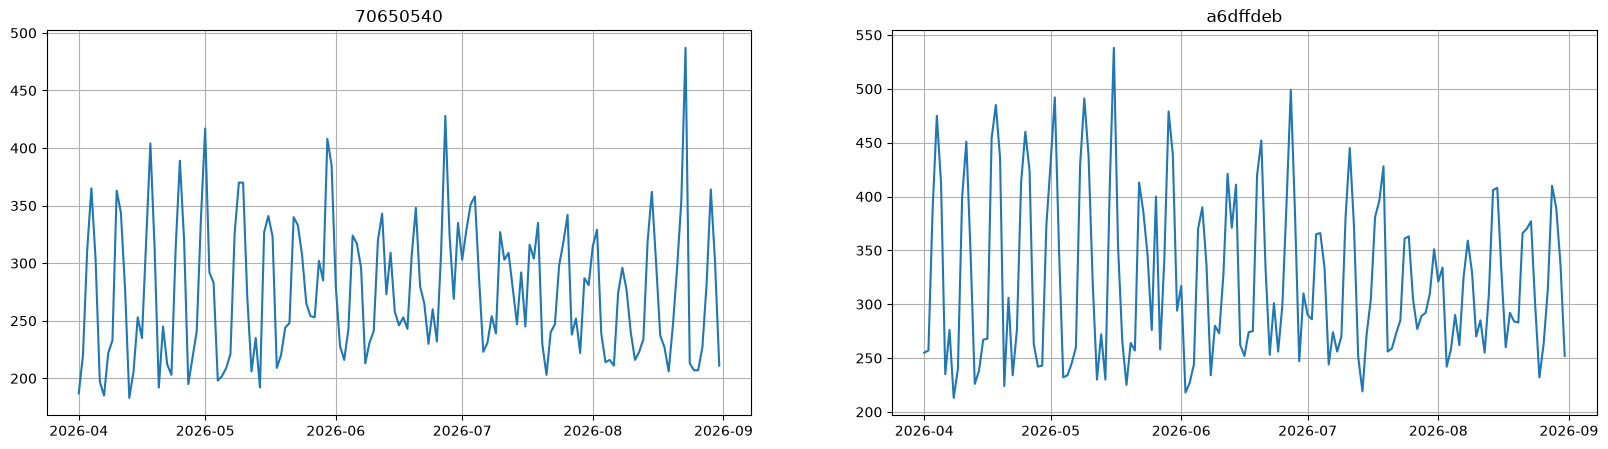

In [18]:
units_df = (pd
.read_csv(filepath_or_buffer=f"{DATA_DIR}/units.csv")
.rename(columns={
    "MaskedUnitId": "segment",
    "UnitSize": "unit_size",
    "PickReason": "pick_reason",
    "TotalOrders":"total_orders"
})
[["segment", "unit_size", "pick_reason", "total_orders"]]

)

orders_df = (
    pd.read_csv(f"{DATA_DIR}/facts-by-date.csv")
    .rename(columns={
        "CalendarDate": "timestamp",
        "MaskedUnitId": "segment",
        "Fact": "target",
    })
    [["timestamp", "segment", "target"]]
)

# Грязно выравниваем дату начала ряда, чтобы данные были по всем юнитам
orders_df = orders_df[orders_df['timestamp'] >= "2026-04-01"]
# Отбираем юниты
orders_sample_df = orders_df.merge(units_df[units_df["unit_size"] == "10+"]["segment"], how="inner", left_on="segment", right_on="segment", copy=True)

orders_sample_ts = TSDataset(orders_sample_df, freq="D")
orders_sample_ts.plot()

### Задание 3. `window` и структурная рекурсия на одном юните

Возьми один юнит (например, самый «busier» из размера `10+`).

1. Выбери `HORIZON` (например, 14 дней) и раздели ряд на train/test.
2. Обучи `MovingAverageModel(window=1)`, сделай прогноз. Обучи для сравнения `NaiveModel(lag=1)` на том же train/test — прогнозы должны совпасть буквально (см. раздел 1.1). Проверь это на цифрах, а не на глаз.
3. Повтори для `window=3`, `window=7`, `window=HORIZON`, `window=HORIZON*2` — визуализируй каждый через `plot_forecast` и посмотри, как форма прогноза меняется с ростом `window`.


Заготовка: [260.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [260.0                                 ] | Факты/Прогнозы: 1/0 | Среднее: 260.00     | Позиция: 1 
Шаг 2  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 2 
Шаг 3  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 3 
Шаг 4  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 4 
Шаг 5  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 5 
Шаг 6  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 6 
Шаг 7  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 7 
Шаг 8  | Окно: [260.0                                 ] | Факты/Прогнозы: 0/1 | Среднее: 260.00     | Позиция: 8

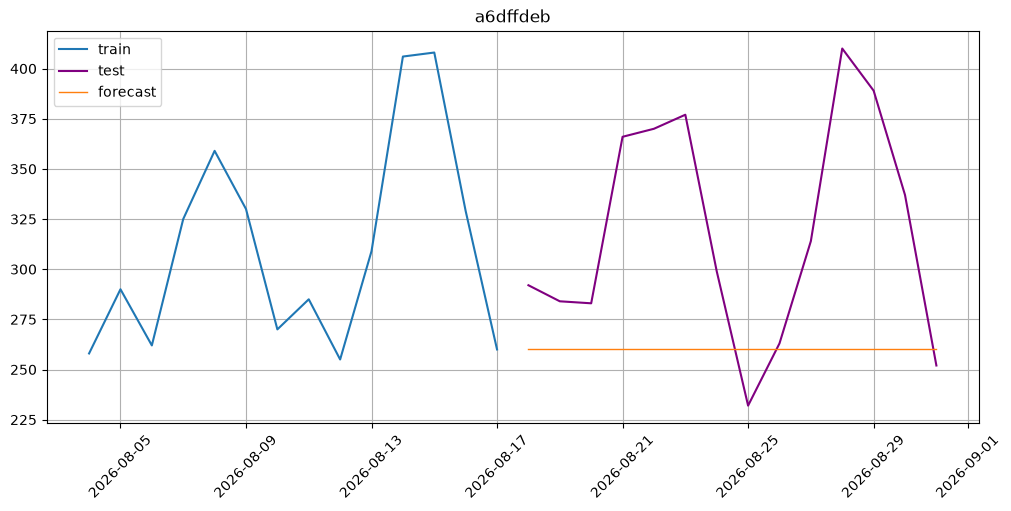

In [23]:
# вернет pandas.core.frame.DataFrame
# orders_sample_ts[:, "a6dffdeb", "target"]

# вернет pandas.core.frame.DataFrame
# orders_sample_ts[:, "a6dffdeb", :]

# вернет etna.datasets.tsdataset.TSDataset
orders_one_ts = TSDataset(df=orders_sample_ts[:, "a6dffdeb", :], freq=orders_sample_ts.freq)

get_forecast(data=orders_one_ts, horizon=14, window=1, seasonality=1, is_log=True)

Заготовка: [408.0, 329.0, 260.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [408.0, 329.0, 260.0                   ] | Факты/Прогнозы: 3/0 | Среднее: 332.33     | Позиция: 3 
Шаг 2  | Окно: [329.0, 260.0, 332.3                   ] | Факты/Прогнозы: 2/1 | Среднее: 307.11     | Позиция: 4 
Шаг 3  | Окно: [260.0, 332.3, 307.1                   ] | Факты/Прогнозы: 1/2 | Среднее: 299.81     | Позиция: 5 
Шаг 4  | Окно: [332.3, 307.1, 299.8                   ] | Факты/Прогнозы: 0/3 | Среднее: 313.09     | Позиция: 6 
Шаг 5  | Окно: [307.1, 299.8, 313.1                   ] | Факты/Прогнозы: 0/3 | Среднее: 306.67     | Позиция: 7 
Шаг 6  | Окно: [299.8, 313.1, 306.7                   ] | Факты/Прогнозы: 0/3 | Среднее: 306.52     | Позиция: 8 
Шаг 7  | Окно: [313.1, 306.7, 306.5                   ] | Факты/Прогнозы: 0/3 | Среднее: 308.76     | Позиция: 9 
Шаг 8  | Окно: [306.7, 306.5, 308.8                   ] | Факты/Прогнозы: 0/3 | Среднее: 307.32   

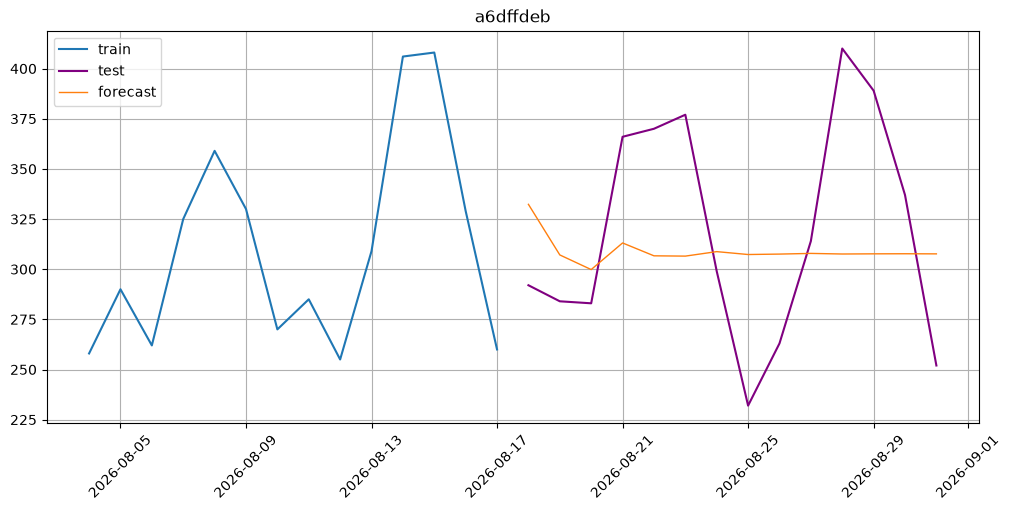

In [24]:
get_forecast(data=orders_one_ts, horizon=14, window=3, seasonality=1, is_log=True)

Заготовка: [285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0] | Факты/Прогнозы: 7/0 | Среднее: 321.71     | Позиция: 7 
Шаг 2  | Окно: [255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 321.7] | Факты/Прогнозы: 6/1 | Среднее: 326.96     | Позиция: 8 
Шаг 3  | Окно: [309.0, 406.0, 408.0, 329.0, 260.0, 321.7, 327.0] | Факты/Прогнозы: 5/2 | Среднее: 337.24     | Позиция: 9 
Шаг 4  | Окно: [406.0, 408.0, 329.0, 260.0, 321.7, 327.0, 337.2] | Факты/Прогнозы: 4/3 | Среднее: 341.27     | Позиция: 10
Шаг 5  | Окно: [408.0, 329.0, 260.0, 321.7, 327.0, 337.2, 341.3] | Факты/Прогнозы: 3/4 | Среднее: 332.03     | Позиция: 11
Шаг 6  | Окно: [329.0, 260.0, 321.7, 327.0, 337.2, 341.3, 332.0] | Факты/Прогнозы: 2/5 | Среднее: 321.17     | Позиция: 12
Шаг 7  | Окно: [260.0, 321.7, 327.0, 337.2, 341.3, 332.0, 321.2] | Факты/Прогнозы: 1/6 | Среднее: 320.06     | Позиция: 13
Шаг 8  

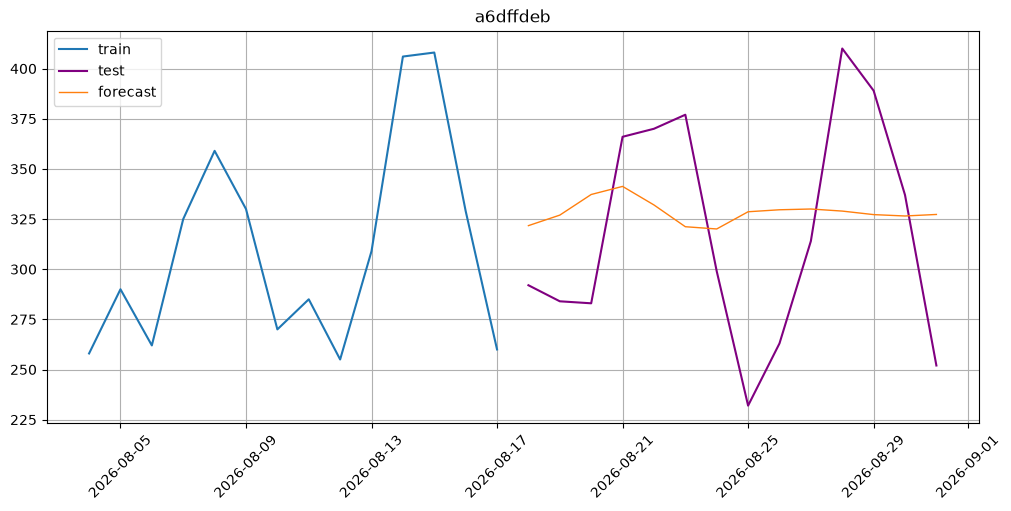

In [25]:
get_forecast(data=orders_one_ts, horizon=14, window=7, seasonality=1, is_log=True)

Заготовка: [258.0, 290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [258.0, 290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0] | Факты/Прогнозы: 14/0 | Среднее: 310.43     | Позиция: 14
Шаг 2  | Окно: [290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 310.4] | Факты/Прогнозы: 13/1 | Среднее: 314.17     | Позиция: 15
Шаг 3  | Окно: [262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 310.4, 314.2] | Факты/Прогнозы: 12/2 | Среднее: 315.90     | Позиция: 16
Шаг 4  | Окно: [325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 310.4, 314.2, 315.9] | Факты/Прогнозы: 11/3 | Среднее: 319.75     | Позиция: 17
Шаг 5  | Окно: [359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 310.4, 314.2, 315.9, 319.8] | Факты/Прогн

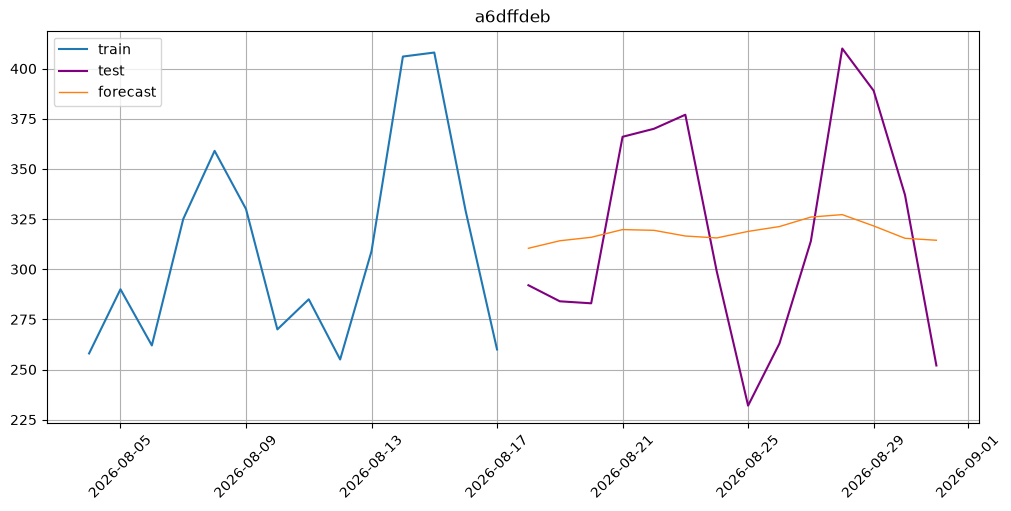

In [26]:
get_forecast(data=orders_one_ts, horizon=14, window=14, seasonality=1, is_log=True)

Заготовка: [259.0, 273.0, 285.0, 361.0, 363.0, 305.0, 277.0, 289.0, 292.0, 310.0, 351.0, 321.0, 334.0, 242.0, 258.0, 290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [259.0, 273.0, 285.0, 361.0, 363.0, 305.0, 277.0, 289.0, 292.0, 310.0, 351.0, 321.0, 334.0, 242.0, 258.0, 290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0] | Факты/Прогнозы: 28/0 | Среднее: 307.43     | Позиция: 28
Шаг 2  | Окно: [273.0, 285.0, 361.0, 363.0, 305.0, 277.0, 289.0, 292.0, 310.0, 351.0, 321.0, 334.0, 242.0, 258.0, 290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 408.0, 329.0, 260.0, 307.4] | Факты/Прогнозы: 27/1 | Среднее: 309.16     | Позиция: 29
Шаг 3  | Окно: [285.0, 361.0, 363.0, 305.0, 277.0, 289.0, 292.0, 310.0, 351.0, 321.0, 334.0, 242.0, 258.0, 290.0, 262.0, 325.0, 359.0, 330.0, 270.0, 285.0, 255.0, 309.0, 406.0, 40

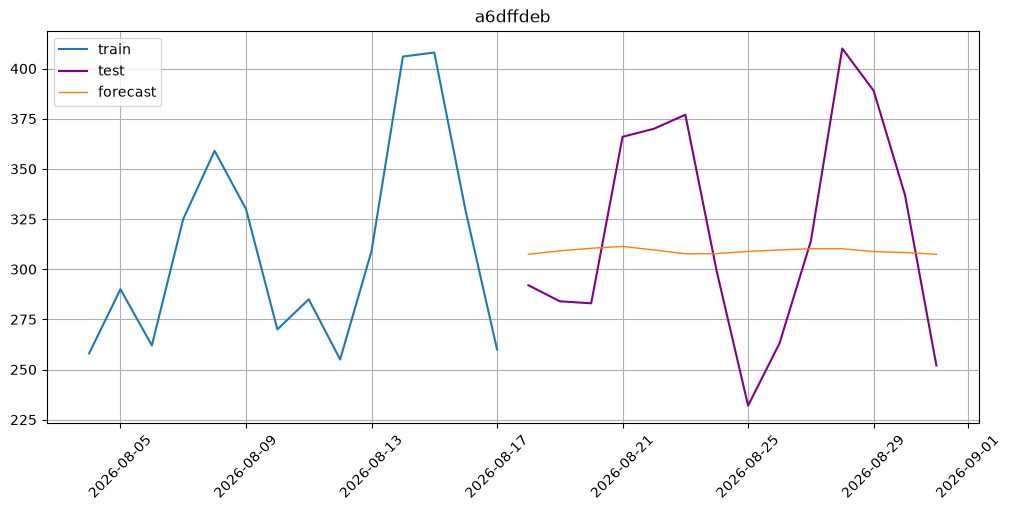

In [27]:
get_forecast(data=orders_one_ts, horizon=14, window=28, seasonality=1, is_log=True)

 ### Задание 4. Выбираем `window` — общая картина по обоим юнитам

1. Обучи `MovingAverageModel` сразу на обоих сегментах для нескольких значений `window` (например, 1, 3, 5, 7, 14).
2. Для каждого `window` посчитай `SMAPE` — per-segment и агрегированно (`mode="macro"`).
3. Сравни — какой `window` даёт наименьшую агрегированную ошибку? Своими словами сформулируй, почему самый большой `window` не обязательно самый лучший (подсказка — раздел 1.3 и Задание 1).


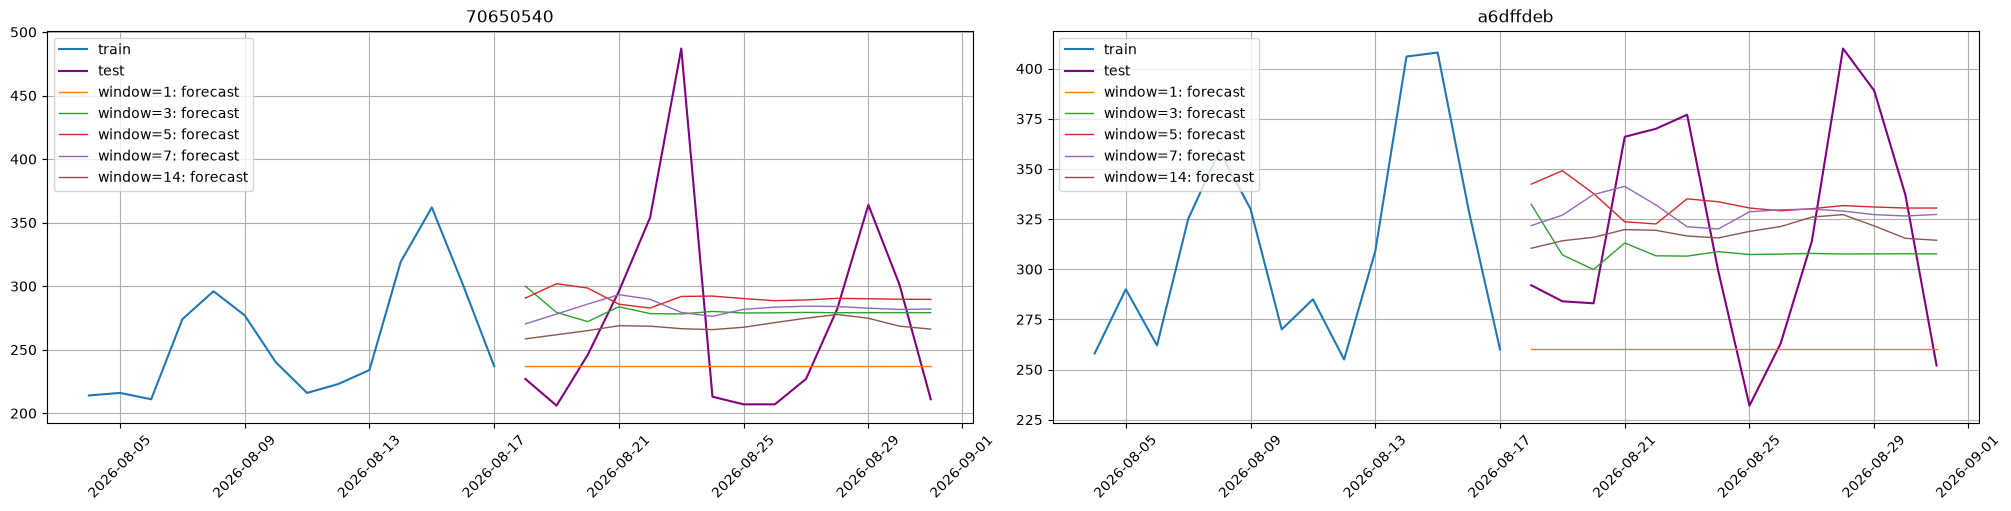

In [79]:
records = []
forecasts_by_window = {}

for w in [1, 3, 5, 7, 14]:
    train_ts, test_ts, forecast_ts = get_forecast(data=orders_sample_ts, horizon=14, window=w, is_log=False)

    smape_agg = SMAPE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
    smape_per_segment = SMAPE()(y_true=test_ts, y_pred=forecast_ts)

    records.append({"window": w, "smape_agg": smape_agg, **smape_per_segment})
    forecasts_by_window[f"window={w}"] = forecast_ts

results_df = pd.DataFrame(records).set_index("window")
results_df.sort_values("window")

# train_ts/test_ts одинаковые на каждой итерации (меняется только window) — берём последние из цикла
plot_forecast(forecast_ts=forecasts_by_window, test_ts=test_ts, train_ts=train_ts, n_train_samples=14)

### Бонус. Общая картина по всем 10 юнитам + логирование

1. Прогони лучший `window` сразу на всех 10 юнитах (используй `orders_df` из Задания 2 без фильтра по `unit_size`).
2. Посчитай весь набор метрик — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно.
3. Собери всё в одну таблицу `result` (`segment`/`unit_size`/`pick_reason`/`total_orders` + все метрики).
4. Залогируй через `log_to_mlflow(...)`, не забудь `tags={"chapter": "ch03", "units_scope": "all_10", "granularity": "day"}` — тогда в MLflow сможешь сравнить с `NaiveModel` прямо в таблице запусков.


In [80]:
BEST_WINDOW = 14
HORIZON = 14

# Все 10 юнитов
orders_ts = TSDataset(orders_df, freq="D")
train_ts, test_ts, forecast_ts = get_forecast(data=orders_ts, horizon=HORIZON, window=BEST_WINDOW, is_log=False)

# Метрики
smape_per_segment = SMAPE()(y_true=test_ts, y_pred=forecast_ts)
wape_per_segment = WAPE()(y_true=test_ts, y_pred=forecast_ts)
mape_per_segment = MAPE()(y_true=test_ts, y_pred=forecast_ts)
mae_per_segment = MAE()(y_true=test_ts, y_pred=forecast_ts)
bias_per_segment = bias(y_true=test_ts, y_pred=forecast_ts)

smape_agg = SMAPE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
mape_agg = MAPE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
mae_agg = MAE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
wape_agg = pooled(test_ts, forecast_ts, signed=False)
bias_agg = pooled(test_ts, forecast_ts, signed=True)

result = units_df.copy()
result["smape"] = result["segment"].map(smape_per_segment)
result["wape"] = result["segment"].map(wape_per_segment)
result["mape"] = result["segment"].map(mape_per_segment)
result["mae"] = result["segment"].map(mae_per_segment)
result["bias"] = result["segment"].map(bias_per_segment)
result.sort_values("smape")


,segment,unit_size,pick_reason,total_orders,smape,wape,mape,mae,bias
4,155082de,5–7,busier (p75),13509,9.652151,0.093755,9.323771,14.451600,-6.731496
5,733e17e8,5–7,typical (p25),12470,9.988926,0.100710,10.125706,13.365698,1.018207
3,9bb64107,3–5,typical (p25),7888,11.501018,0.112918,11.730542,9.485089,-2.123728
0,a6dffdeb,10+,busier (p75),29099,14.537399,0.144752,14.898052,46.196631,-0.258477
2,3bfb39ef,3–5,busier (p75),9530,14.685595,0.148303,15.372066,15.889554,2.567920
7,d3319417,7–10,typical (p25),17464,15.733712,0.158703,15.024294,30.391635,-6.566654
6,aa88e1ec,7–10,busier (p75),19363,17.097198,0.173929,17.767235,33.667695,2.741023
8,8a399130,<3,busier (p75),5646,20.330859,0.209814,23.090555,10.850394,12.700014
1,70650540,10+,typical (p25),25437,21.246003,0.221057,21.178791,60.443225,-1.878582
9,a5cd0472,<3,typical (p25),4051,24.741076,0.219418,53.420985,8.698376,10.835132


In [81]:
# Логируем
log_to_mlflow(
    model_name="MovingAverageModel",
    model_params={"window": BEST_WINDOW, "horizon": HORIZON},
    metrics={
        "smape_macro": smape_agg,
        "mape_macro": mape_agg,
        "mae_macro": mae_agg,
        "wape_pooled": wape_agg,
        "bias_pooled": bias_agg,
    },
    metrics_per_segment={
        "smape": smape_per_segment,
        "wape": wape_per_segment,
        "mape": mape_per_segment,
        "mae": mae_per_segment,
        "bias": bias_per_segment,
    },
    segment_table=result,
    tags={"chapter": "ch03", "units_scope": "all_10", "granularity": "day"},
    run_name_suffix="ch03_all_10_day",
)
